In [1]:
# Dataset: https://www.kaggle.com/datasets/amanalisiddiqui/fraud-detection-dataset

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("data.csv")
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [4]:
df.drop(columns="step", inplace=True)
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [5]:
fraud_pct = df["isFraud"].value_counts()[1] / df.shape[0] * 100
print("Percent of fraudulent transactions:", fraud_pct)

Percent of fraudulent transactions: 0.12908204481801522


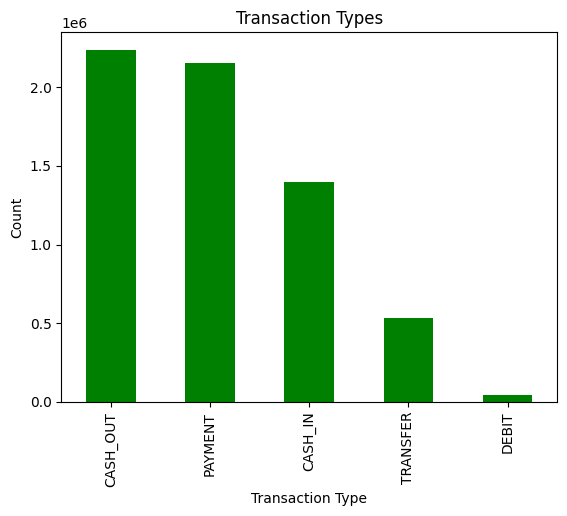

In [6]:
df["type"].value_counts().plot(kind="bar", title="Transaction Types", color="green")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.show()

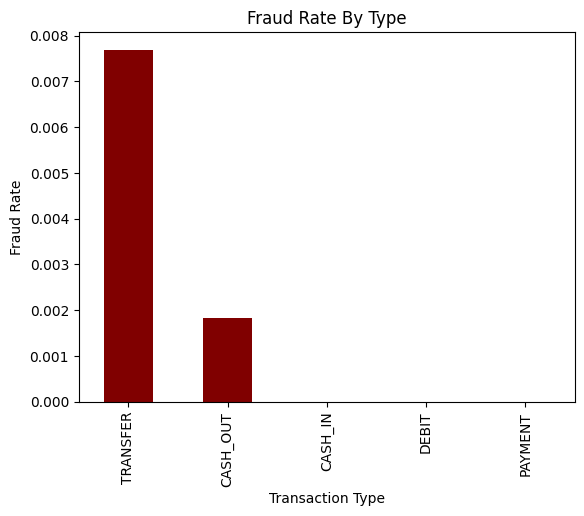

In [7]:
fraud_by_type = df.groupby("type")["isFraud"].mean().sort_values(ascending=False)
fraud_by_type.plot(kind="bar", title="Fraud Rate By Type", color="maroon")
plt.xlabel("Transaction Type")
plt.ylabel("Fraud Rate")
plt.show()

In [8]:
# Make correlation matrix
corr = df[["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "isFraud"]].corr()
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


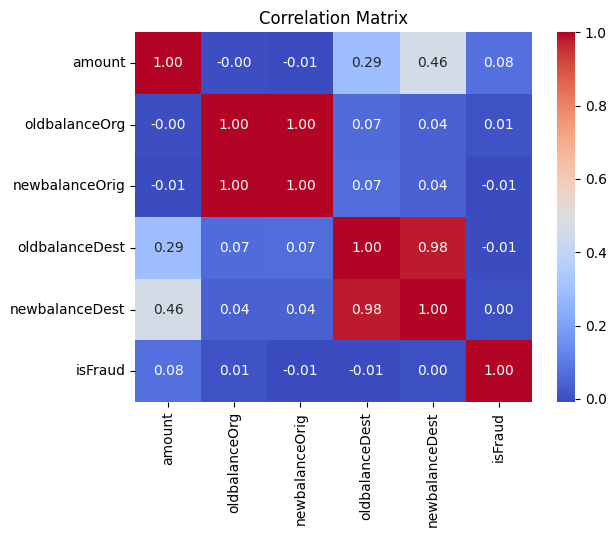

In [9]:
# Visualize correlation matrix with heatmap
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [11]:
# Feature engineering
df_model = df.copy()
df_model["balanceDiffOrig"] = df_model["oldbalanceOrg"] - df_model["newbalanceOrig"]
df_model["balanceDiffDest"] = df_model["newbalanceDest"] - df_model["oldbalanceDest"]
df_model["zero_balance_transfer"] = ((df_model["oldbalanceOrg"] > 0) & (df_model["newbalanceOrig"] == 0)).astype(int)
df_model["amount_to_oldbal"] = df_model["amount"] / (df_model["oldbalanceOrg"] + 1)
df_model["same_orig_dest"] = (df_model["nameOrig"] == df_model["nameDest"]).astype(int)
df_model.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrig,balanceDiffDest,zero_balance_transfer,amount_to_oldbal,same_orig_dest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0,0,0.057834,0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0,0,0.087731,0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0,1,0.994505,0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0,1,0.994505,0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0,0,0.280788,0


In [12]:
features = ["type", "amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest",
            "balanceDiffOrig", "balanceDiffDest", "zero_balance_transfer", "amount_to_oldbal", "same_orig_dest"]
X = df_model[features]
y = df_model["isFraud"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [13]:
# Build preprocessor
numeric = ["amount", "oldbalanceOrg", "newbalanceOrig", "oldbalanceDest", "newbalanceDest", "balanceDiffOrig", "balanceDiffDest", "amount_to_oldbal", "zero_balance_transfer", "same_orig_dest"]
categorical = ["type"]
preprocessor = ColumnTransformer([("num", StandardScaler(), numeric), ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical)], remainder="drop")

In [ ]:
# Build model pipeline with Random Forest Classifier
pipeline = Pipeline([("prep", preprocessor), ("clf", RandomForestClassifier(random_state=42, n_jobs=-1))])

# Hyperparameter tuning with RandomizedSearchCV
param_dist = {
    "clf__n_estimators": [100, 200, 500],
    "clf__max_depth": [5, 10, 20, None],
    "clf__min_samples_split": [2, 5, 10],
    "clf__min_samples_leaf": [1, 2, 4],
    "clf__max_features": ["sqrt", "log2", 0.5],
    "clf__class_weight": [None, "balanced"]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rs = RandomizedSearchCV(pipeline, param_distributions=param_dist, n_iter=20, scoring="f1", n_jobs=-1, cv=cv, verbose=2, random_state=42)
rs.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
[CV] END clf__class_weight=None, clf__max_depth=20, clf__max_features=0.5, clf__min_samples_leaf=1, clf__min_samples_split=5, clf__n_estimators=200; total time=  18.0s
[CV] END clf__class_weight=None, clf__max_depth=20, clf__max_features=0.5, clf__min_samples_leaf=1, clf__min_samples_split=5, clf__n_estimators=200; total time=  18.2s
[CV] END clf__class_weight=None, clf__max_depth=20, clf__max_features=0.5, clf__min_samples_leaf=1, clf__min_samples_split=5, clf__n_estimators=200; total time=  18.3s
[CV] END clf__class_weight=None, clf__max_depth=20, clf__max_features=0.5, clf__min_samples_leaf=1, clf__min_samples_split=5, clf__n_estimators=200; total time=  18.3s
[CV] END clf__class_weight=None, clf__max_depth=20, clf__max_features=0.5, clf__min_samples_leaf=1, clf__min_samples_split=5, clf__n_estimators=200; total time=  18.5s
[CV] END clf__class_weight=balanced, clf__max_depth=None, clf__max_features=0.5, clf__min_samples_

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'clf__class_weight': [None, 'balanced'], 'clf__max_depth': [5, 10, ...], 'clf__max_features': ['sqrt', 'log2', ...], 'clf__min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategie

In [15]:
model = rs.best_estimator_
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1906322
           1       0.95      0.73      0.83      2464

    accuracy                           1.00   1908786
   macro avg       0.97      0.87      0.91   1908786
weighted avg       1.00      1.00      1.00   1908786



In [17]:
print("ROC-AUC score:", roc_auc_score(y_test, y_prob))

ROC-AUC score: 0.9969964414211882


In [ ]:
# Pickle trained model for Streamlit app use
import pickle

with open("fraud_model.pkl", "wb") as f:
    pickle.dump(model, f)